# CNN 卷积神经网络基础

### 什么是 CNN？

CNN（Convolutional Neural Network）是专门用于处理图像的神经网络。它的核心思想是：用一个小窗口（卷积核）在图片上滑动，提取局部特征（比如边缘、纹理、形状）。

### 和全连接网络的区别

全连接网络处理图片时，需要把 28x28 的图片展平成 784 维向量，丢失了空间信息（像素之间的位置关系）。CNN 直接在二维图片上操作，保留了空间结构。

### CNN 的三大组件

1. **卷积层（Conv2d）**：用卷积核提取特征
2. **池化层（MaxPool2d）**：缩小特征图尺寸，保留重要信息
3. **全连接层（Linear）**：最终分类

In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False                  # 解决负号显示问题

## 1. 卷积层 Conv2d

### 核心概念

- 卷积核（kernel/filter）：一个小矩阵，在图片上滑动，提取特征
- in_channels：输入的通道数（灰度图=1，RGB=3）
- out_channels：输出通道数（用多少个不同的卷积核，就产生多少个通道）
- kernel_size：卷积核的大小（3 表示 3x3）
- stride：每次滑动几步
- padding：在边缘补零，控制输出大小

### 输出大小公式

output_size = (input_size - kernel_size + 2*padding) / stride + 1

In [5]:
# 卷积层演示
# 模拟一张 1x28x28 的灰度图片
input_img = torch.randn(1, 1, 28, 28)  # (batch, channels, height, width)

# 一个卷积层：1个输入通道，16个输出通道，3x3卷积核，padding=1保持尺寸不变
conv = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
output = conv(input_img)

print(f"输入形状: {input_img.shape}")
print(f"卷积核大小: 3x3")
print(f"输出形状: {output.shape}")  # (1, 16, 28, 28)
print(f"\n解释: 1张图片 → 16个特征图，每个 28x28")

输入形状: torch.Size([1, 1, 28, 28])
卷积核大小: 3x3
输出形状: torch.Size([1, 16, 28, 28])

解释: 1张图片 → 16个特征图，每个 28x28


findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found 

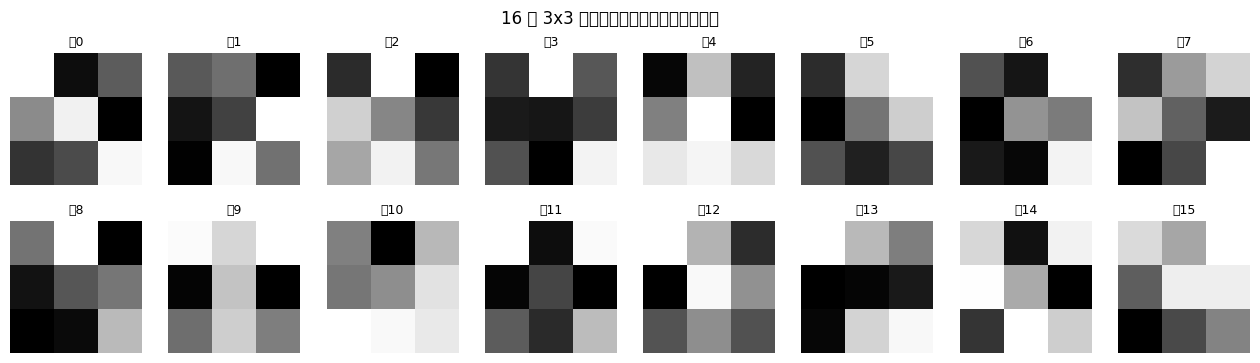

In [6]:
# 可视化卷积核学到的特征
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    # 取第 i 个卷积核的权重
    kernel = conv.weight[i, 0].detach().numpy()
    ax = axes[i // 8][i % 8]
    ax.imshow(kernel, cmap='gray')
    ax.set_title(f"核{i}", fontsize=9)
    ax.axis('off')
plt.suptitle('16 个 3x3 卷积核（训练前的随机初始化）')
plt.show()

In [7]:
# 不同参数的效果对比
configs = [
    (1, 16, 3, 1, 0, 1),    # kernel=3, stride=1, padding=0
    (1, 16, 3, 1, 1, 1),    # kernel=3, stride=1, padding=1
    (1, 16, 5, 1, 0, 1),    # kernel=5, stride=1, padding=0
    (1, 16, 3, 2, 1, 1),    # kernel=3, stride=2, padding=1
]

x = torch.randn(1, 1, 28, 28)
for in_c, out_c, k, s, p, _ in configs:
    layer = nn.Conv2d(in_c, out_c, kernel_size=k, stride=s, padding=p)
    out = layer(x)
    print(f"kernel={k}, stride={s}, padding={p}: {x.shape} → {out.shape}")

kernel=3, stride=1, padding=0: torch.Size([1, 1, 28, 28]) → torch.Size([1, 16, 26, 26])
kernel=3, stride=1, padding=1: torch.Size([1, 1, 28, 28]) → torch.Size([1, 16, 28, 28])
kernel=5, stride=1, padding=0: torch.Size([1, 1, 28, 28]) → torch.Size([1, 16, 24, 24])
kernel=3, stride=2, padding=1: torch.Size([1, 1, 28, 28]) → torch.Size([1, 16, 14, 14])


## 2. 池化层 MaxPool2d

### 作用

在保留重要特征的同时缩小特征图的尺寸。最常用的是最大池化——在每个小区域中取最大值。

### 为什么需要池化？

- 减少计算量：特征图变小了，后续层的参数更少
- 增加感受野：后续的卷积核能看到更大范围的原图
- 增强鲁棒性：对微小的位置变化不敏感

In [8]:
# 池化层演示
x = torch.randn(1, 16, 28, 28)

pool = nn.MaxPool2d(kernel_size=2, stride=2)  # 2x2 窗口，步长2
output = pool(x)

print(f"池化前: {x.shape}")
print(f"池化后: {output.shape}")
print(f"尺寸缩小了一半: 28 → 14")

池化前: torch.Size([1, 16, 28, 28])
池化后: torch.Size([1, 16, 14, 14])
尺寸缩小了一半: 28 → 14


## 3. 完整的 CNN 网络

一个典型的 CNN 结构：

```
输入图片 → [卷积+ReLU+池化] × N → 展平 → 全连接层 → 输出
```

下面我们构建一个用于 MNIST 手写数字识别的 CNN。

In [9]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 第一组卷积：提取低级特征（边缘、角点）
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # 1→32 通道
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)  # 28x28 → 14x14

        # 第二组卷积：提取高级特征（形状、图案）
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32→64 通道
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)  # 14x14 → 7x7

        # 全连接层：分类
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # 展平后接全连接
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)          # 10个数字

    def forward(self, x):
        # x: (batch, 1, 28, 28)
        x = self.pool1(self.relu1(self.conv1(x)))  # → (batch, 32, 14, 14)
        x = self.pool2(self.relu2(self.conv2(x)))  # → (batch, 64, 7, 7)
        x = x.view(x.size(0), -1)                  # 展平 → (batch, 3136)
        x = self.relu3(self.fc1(x))                # → (batch, 128)
        x = self.fc2(x)                             # → (batch, 10)
        return x

model = CNN()
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\n总参数量: {total_params:,}")

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

总参数量: 421,642


In [10]:
# 验证数据流动的形状变化
x = torch.randn(1, 1, 28, 28)
print(f"输入: {x.shape}")

x = model.conv1(x);  print(f"conv1: {x.shape}")
x = model.relu1(x);  print(f"relu1: {x.shape}")
x = model.pool1(x);  print(f"pool1: {x.shape}")
x = model.conv2(x);  print(f"conv2: {x.shape}")
x = model.relu2(x);  print(f"relu2: {x.shape}")
x = model.pool2(x);  print(f"pool2: {x.shape}")
x = x.view(x.size(0), -1); print(f"flatten: {x.shape}")
x = model.fc1(x);    print(f"fc1: {x.shape}")
x = model.relu3(x);  print(f"relu3: {x.shape}")
x = model.fc2(x);    print(f"fc2: {x.shape}")

输入: torch.Size([1, 1, 28, 28])
conv1: torch.Size([1, 32, 28, 28])
relu1: torch.Size([1, 32, 28, 28])
pool1: torch.Size([1, 32, 14, 14])
conv2: torch.Size([1, 64, 14, 14])
relu2: torch.Size([1, 64, 14, 14])
pool2: torch.Size([1, 64, 7, 7])
flatten: torch.Size([1, 3136])
fc1: torch.Size([1, 128])
relu3: torch.Size([1, 128])
fc2: torch.Size([1, 10])
